In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
#all necessary libraries
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split

2024-11-13 13:23:36.197740: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1731475416.324590    5675 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1731475416.356422    5675 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-13 13:23:36.614224: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
#constants
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 200

In [6]:
import glob

folder_path = '/home/natsu/MechAI/Dataset/disk_rotor/'
for file_path in glob.glob(folder_path + '*.ipynb_checkpoints'):
    with open(file_path, 'r') as f:
        # Process the file
        print(f.read())


In [7]:
CLASSES = os.listdir('/home/natsu/MechAI/Dataset')
dataset_dir = '/home/natsu/MechAI/Dataset'
data = []
labels = []

for label in CLASSES:
    class_dir = os.path.join(dataset_dir, label)
    for img_name in os.listdir(class_dir):
        img_path = os.path.join(class_dir, img_name)
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=IMAGE_SIZE)
        img_array = tf.keras.preprocessing.image.img_to_array(img)
        data.append(img_array)
        labels.append(label)

In [8]:
# Convert lists to arrays
data = np.array(data) / 255.0
labels = np.array(labels)

In [9]:
# Encode labels
label_map = {label: idx for idx, label in enumerate(CLASSES)}
labels = np.vectorize(label_map.get)(labels)

In [10]:
# Split the data
X_train, X_val, y_train, y_val = train_test_split(data, labels, test_size=0.2, random_state=42)

In [11]:
# Data Augmentation
train_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator()

In [12]:
# Model Architecture
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(CLASSES), activation='softmax')
])

I0000 00:00:1731475521.745874    5675 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4778 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060, pci bus id: 0000:01:00.0, compute capability: 7.5


In [ ]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Train the model
history = model.fit(
    train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=val_datagen.flow(X_val, y_val, batch_size=BATCH_SIZE),
    epochs=EPOCHS,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    validation_steps=len(X_val) // BATCH_SIZE
)

In [ ]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(val_datagen.flow(X_val, y_val, batch_size=BATCH_SIZE))
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


In [ ]:
# Save the model
model_path = "car_parts_classifier.h5"
model.save(model_path)
print(f"Model saved at {model_path}")

In [ ]:
# Plot accuracy and loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [13]:
# Load the trained model
model_path = "car_parts_classifier.h5"
model = load_model(model_path)

I0000 00:00:1731475528.053333    6073 service.cc:148] XLA service 0x7cc094005cf0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1731475528.053540    6073 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 2060, Compute Capability 7.5
2024-11-13 13:25:28.073827: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1731475528.123944    6073 cuda_dnn.cc:529] Loaded cuDNN version 90300
2024-11-13 13:25:28.847760: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[1,128,28,28]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,64,30,30]{3,2,1,0}, f32[128,64,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"acti

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


I0000 00:00:1731475529.136616    6073 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


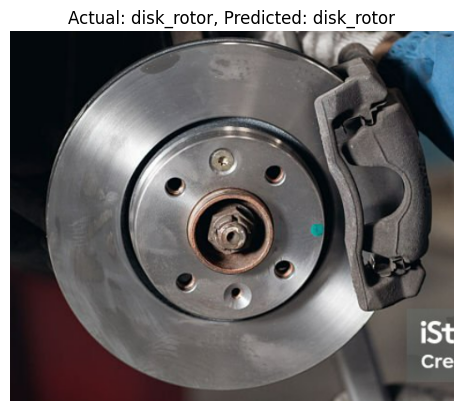

In [14]:
def preprocess_image(img_path):
    """
    Load an image, convert it to RGB, resize it to the required dimensions, and scale it.
    """
    img = cv2.imread(img_path)                       # Load the image
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)       # Convert BGR to RGB
    img = cv2.resize(img, IMAGE_SIZE)                # Resize image
    img = img / 255.0                                # Normalize pixel values
    img = np.expand_dims(img, axis=0)                # Expand dims to fit model input
    return img


def predict_image(img_path, actual_label=None):
    """
    Predict the class of an image, then display the image with actual and predicted labels.
    """
    img = preprocess_image(img_path)
    prediction = model.predict(img)
    predicted_class = CLASSES[np.argmax(prediction)]

    # Display the image with OpenCV
    original_img = cv2.imread(img_path)
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)  # Convert to RGB for display

    plt.imshow(original_img)
    plt.axis('off')
    title = f"Predicted: {predicted_class}"
    if actual_label:
        title = f"Actual: {actual_label}, " + title
    plt.title(title)
    plt.show()

# Test the function with an example image
test_image_path = "/home/natsu/MechAI/Dataset/disk_rotor/disk_rotor_1.png"   # Replace with actual image path
actual_label = "disk_rotor"                  # Replace with actual label if known
predict_image(test_image_path, actual_label)

In [17]:
import cv2
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model

# Define constants
IMAGE_SIZE = (224, 224)  # Replace with the model's required image size
CLASSES = os.listdir('/home/natsu/MechAI/Dataset')  # Replace with actual classes
model_path = "car_parts_classifier.h5"
model = load_model(model_path)

def preprocess_image(img):
    """
    Convert the captured frame to RGB, resize it, scale it, and prepare for prediction.
    """
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)       # Convert BGR to RGB
    img = cv2.resize(img, IMAGE_SIZE)                # Resize to model's input size
    img = img / 255.0                                # Normalize pixel values
    img = np.expand_dims(img, axis=0)                # Expand dims to fit model input
    return img

def predict_image_from_camera():
    """
    Capture image from the camera, predict the class, and display in a new window
    with bounding box and label on each frame.
    """
    cap = cv2.VideoCapture(2)  # 0 is typically the default camera; adjust if necessary

    # Create a named window for the live feed
    cv2.namedWindow("Live Prediction Feed", cv2.WINDOW_NORMAL)
    cv2.resizeWindow("Live Prediction Feed", 800, 600)  # Resize window as needed

    while True:
        ret, frame = cap.read()
        if not ret:
            print("Failed to grab frame")
            break
        
        # Preprocess the captured frame
        img = preprocess_image(frame)
        
        # Predict the class
        prediction = model.predict(img)
        predicted_class = CLASSES[np.argmax(prediction)]
        
        # Draw a bounding box on the frame
        height, width, _ = frame.shape
        start_point = (int(width * 0.25), int(height * 0.25))  # Top-left corner
        end_point = (int(width * 0.75), int(height * 0.75))    # Bottom-right corner
        color = (0, 255, 0)  # Green color for bounding box
        thickness = 2
        frame = cv2.rectangle(frame, start_point, end_point, color, thickness)
        
        # Put the predicted class label inside the bounding box
        label = f"Predicted: {predicted_class}"
        cv2.putText(frame, label, (start_point[0], start_point[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

        # Display the frame in the live feed window
        cv2.imshow("Live Prediction Feed", frame)

        # Exit on pressing 'q'
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    # Release the capture and close the live feed window
    cap.release()
    cv2.destroyAllWindows()


In [18]:
# Run the function to start the live feed with predictions
predict_image_from_camera()

Failed to grab frame


[ WARN:0@184.421] global cap_v4l.cpp:999 open VIDEOIO(V4L2:/dev/video2): can't open camera by index
[ERROR:0@184.534] global obsensor_uvc_stream_channel.cpp:158 getStreamChannelGroup Camera index out of range
QObject::moveToThread: Current thread (0xad3ab20) is not the object's thread (0xacb4560).
Cannot move to target thread (0xad3ab20)

QObject::moveToThread: Current thread (0xad3ab20) is not the object's thread (0xacb4560).
Cannot move to target thread (0xad3ab20)

QObject::moveToThread: Current thread (0xad3ab20) is not the object's thread (0xacb4560).
Cannot move to target thread (0xad3ab20)

QObject::moveToThread: Current thread (0xad3ab20) is not the object's thread (0xacb4560).
Cannot move to target thread (0xad3ab20)

QObject::moveToThread: Current thread (0xad3ab20) is not the object's thread (0xacb4560).
Cannot move to target thread (0xad3ab20)

QObject::moveToThread: Current thread (0xad3ab20) is not the object's thread (0xacb4560).
Cannot move to target thread (0xad3ab20)
